In [1]:
import os

import numpy as np
import pandas as pd

from tqdm import tqdm

from matplotlib import pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns

from aicsimageio import AICSImage

from cellpose import models

from skimage import io, filters, measure

from scipy import ndimage, optimize

import napari

24-Sep-26 15:44:20 - bfio.backends - WARNING  - Java backend is not available. This could be due to a missing dependency (jpype).


In [2]:
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial"]
plt.rcParams["svg.fonttype"] = "none"

# General information

FRAP traces were collected in HCT116 OsTIRF74G biallelic mAC-POLR2A cells using a Zeiss LSM900.

Mean intensity of two nuclear circular ROIs were collected, one bleached after 10 s and one unbleached control. During acquisition, only these regions were illuminated to reduce photobleaching.

FRAP was performed in the green, GFP channel on the mClover fluorescence of mAC-POLR2A treated with 5-Ph-IAA at 10 nM, 100 nM, or 1 µM for 4 - 5 hours, 100 nM for 1 - 1.5 hours, or vehicle.

Control FRAP traces collected from fixed cells showed no recovery, and were used to define the 0 value post-bleach, with the assumption that this represents the extent of bleaching in a completely immobilised population.

FRAP traces were first normalised to the pre-bleach baseline, then the bleached ROI normalised between this 0% value and the unbleached control intensity as 100%.

Fraction of POLR2A mobile was calculcated by the plateau of a single-exponential fit to the fluorescence recovery post-bleach. This was multiplied by the pre-bleach fluorescence intensity to estimate abundance of mobile and immobile POLR2A, relative to vehicle-treated mAC-POLR2A cells.

# FRAP traces collected from fixed cells are used to define 0 value

## load fixed controls to find postbleach zero values

In [3]:
FIXED_GREEN = ["250113_mACmChPOLR2A_FRAP_FIXED/WELL5_mACPOLR2A_FIXED_GREEN/"]
            
LS_GREEN_F = []

for i, n in enumerate(FIXED_GREEN):
    LS_GREEN_F.append([])
    for x in os.listdir(n):
        if x.endswith("csv"):
            LS_GREEN_F[i].append(x)

In [4]:
fixed_green_dfs = []


for i, n in enumerate(FIXED_GREEN):
    for c in LS_GREEN_F[i]:
        f = pd.read_csv(n + c)

        frame = f.index.tolist()
        t = f['Time::Relative Time!!R'][1:94]
        gfp_c = f['Channel1_R1_IntensityMean::EGFP_R1_IntensityMean!!R'][1:94]
        gfp_b = f['Channel1_R2_IntensityMean::EGFP_R2_IntensityMean!!R'][1:94]
        
        date = n[:6]

        baseline_c = np.mean(gfp_c[:30])
        baseline_b = np.mean(gfp_b[:30])

        gfp_c_n = [100*(i/baseline_c) for i in gfp_c]
        gfp_b_n = [100*(i/baseline_b) for i in gfp_b]

        GFP_DF1 = pd.DataFrame({
            'DATE' : np.tile(date, len(t)),
            'FILE' : np.tile(n+c, len(t)),
            'FRAME' : range(0,len(t)),
            'TIME' : t,
            'BLEACH' : np.tile('Control', len(t)),
            'INTENSITY' : gfp_c,
            'INTENSITY_PCT' : gfp_c_n})

        GFP_DF2 = pd.DataFrame({
            'DATE' : np.tile(date, len(t)),
            'FILE' : np.tile(n+c, len(t)),
            'FRAME' : range(0,len(t)),
            'TIME' : t,
            'BLEACH' : np.tile('Bleached', len(t)),
            'INTENSITY' : gfp_b,
            'INTENSITY_PCT' : gfp_b_n })

        GFP_DF = pd.concat([GFP_DF1, GFP_DF2])

        fixed_green_dfs.append(GFP_DF)
        
mClover_Fixed_Data = pd.concat(fixed_green_dfs)

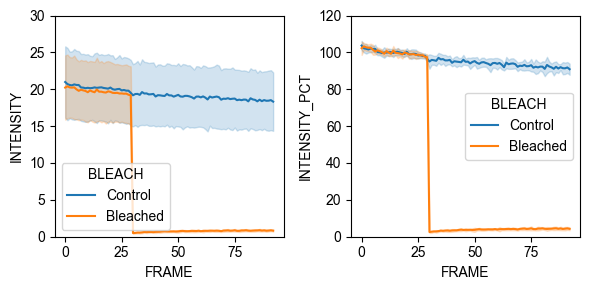

In [5]:
f, a = plt.subplots(ncols = 2, figsize = (6,3))

sns.lineplot(mClover_Fixed_Data,
              x = 'FRAME', 
                y = 'INTENSITY', 
                hue = 'BLEACH',
               errorbar = 'sd',
             ax = a[0])

sns.lineplot(mClover_Fixed_Data,
              x = 'FRAME', 
                y = 'INTENSITY_PCT', 
                hue = 'BLEACH',
               errorbar = 'sd',
             ax = a[1])

a[0].set_ylim(0,30)
a[1].set_ylim(0,120)

plt.tight_layout()

## average post-bleach fluorescence intensity to determine zero value

In [6]:
mClover_Fixed_ZeroValue = mClover_Fixed_Data.query('FRAME >= 30 & BLEACH == "Bleached"').INTENSITY_PCT.mean()

In [7]:
mClover_Fixed_ZeroValue

3.9353035646213197

# Load and inspect raw FRAP data from multiple experiments

## define subdirectories and experimental conditions

In [8]:
SUBDIRS_GREEN = ["250926_mACPOLR2A_FRAP/WELL05_VEH_120320min/", 
                 "250926_mACPOLR2A_FRAP/WELL02_10nM_240320min/", 
                 "250926_mACPOLR2A_FRAP/WELL06_100nM_6090min/", 
                 "250926_mACPOLR2A_FRAP/WELL03_100nM_240320min/", 
                 "250926_mACPOLR2A_FRAP/WELL07_1uM_240320min/",
                 "250929_mACPOLR2A_FRAP/WELL01_VEH_120320MIN/",
                 "250929_mACPOLR2A_FRAP/WELL05_10nM_240320MIN/",
                 "250929_mACPOLR2A_FRAP/WELL02_100nM_6090MIN/",
                 "250929_mACPOLR2A_FRAP/WELL06_100nM_240320MIN/",
                 "250929_mACPOLR2A_FRAP/WELL07_1uM_240320MIN/",
                 "251010_mACPOLR2A_FRAP/WELL05_VEH_120320MIN/",
                 "251010_mACPOLR2A_FRAP/WELL01_10nM_240320MIN/",
                 "251010_mACPOLR2A_FRAP/WELL06_100nM_6090MIN/",
                 "251010_mACPOLR2A_FRAP/WELL02_1uM_240320MIN/",
                 "251010_mACPOLR2A_FRAP/WELL03_100nM_240320MIN/"]


In [9]:
SUBDIRS_GREEN_COND = ['VEHICLE',
                      '10 nM, 240-350 min',
                      '100 nM, 60-90 min',
                      '100 nM, 240-350 min',
                      '1 µM, 240-350 min',
                      'VEHICLE',
                      '10 nM, 240-350 min',
                      '100 nM, 60-90 min',
                      '100 nM, 240-350 min',
                      '1 µM, 240-350 min',
                      'VEHICLE',
                      '10 nM, 240-350 min',
                      '100 nM, 60-90 min',
                      '100 nM, 240-350 min',
                      '1 µM, 240-350 min']

In [10]:
condition_order = ['VEHICLE', 
                   '10 nM, 240-350 min', 
                   '100 nM, 60-90 min',
                   '100 nM, 240-350 min', 
                   '1 µM, 240-350 min']

## Examine mClover fluorescence intensity from snaps of nuclei taken pre-FRAP

In [11]:
LS_GREEN = []

for i, n in enumerate(SUBDIRS_GREEN):
    LS_GREEN.append([])
    for x in os.listdir(n):
        if x.endswith("SNAP.czi"):
            LS_GREEN[i].append(x)

In [12]:
files = []
conditions = []
dates = []

ars = []
ints_green = []

green_labels = []


for i, n in enumerate(SUBDIRS_GREEN):
    for c in tqdm(LS_GREEN[i]):
        img = AICSImage(n + "/" + c).get_image_data('YX')
        
        t = filters.threshold_mean(filters.gaussian(img, sigma = 1))
        h = filters.gaussian(img, sigma = 1) > t
        mask = ndimage.label(h)[0]
        
        if len(np.unique(mask)) > 1:
            props = measure.regionprops_table(mask, 
                                      intensity_image = img,
                                     properties = ['label', 'area', 'intensity_mean'])
            bigloc = np.argmax(props['area']) + 1
            ar = props['area'][props['label'] == bigloc][0]
            int_green = props['intensity_mean'][props['label'] == bigloc][0]
            
            green_labels.append(mask == bigloc)

            files.append(n+c)
            conditions.append(SUBDIRS_GREEN_COND[i])
            dates.append(n[:6])
            ars.append(ar)
            ints_green.append(int_green)
            
mClover_On_DF = pd.DataFrame({'DATE' : dates,
                              'CONDITION' : conditions,
                             'FILE': files,
                             'AREA' : ars,
                            'INTENSITY_MCLOVER' : ints_green})

100%|███████████████████████████████████████████| 15/15 [00:00<00:00, 22.46it/s]


/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_57008/3710710192.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  a.set_xticklabels(xlabels, rotation=90)
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_57008/3710710192.py:23: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


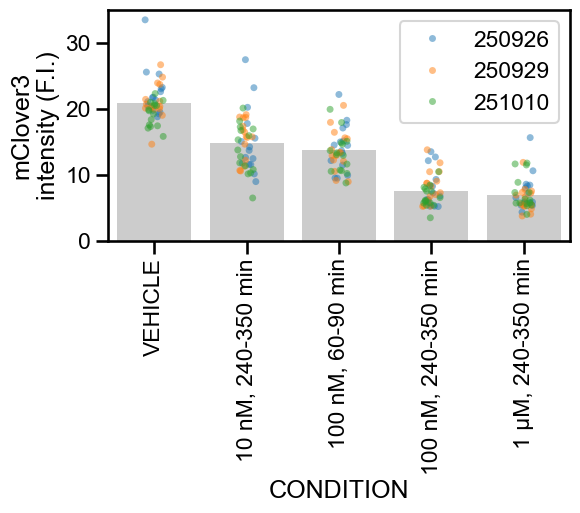

In [13]:
sns.set_context('talk')

f , a = plt.subplots(ncols = 1, figsize = (9,3))

sns.stripplot(mClover_On_DF, x = 'CONDITION', hue = 'DATE', y = 'INTENSITY_MCLOVER', ax = a, size = 5, alpha = 0.5)

sns.barplot(mClover_On_DF, x = 'CONDITION', y = 'INTENSITY_MCLOVER', ax = a, alpha = 0.2, errorbar = None, color = 'black')

a.set_ylim(0,35)



xlabels = a.get_xticklabels()

a.set_xticklabels(xlabels, rotation=90)

a.set_box_aspect(0.5)

a.set_ylabel('mClover3\nintensity (F.I.)')

a.legend(bbox_to_anchor = (1,1))

plt.tight_layout()

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_57008/2072912130.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  a.set_xticklabels(xlabels, rotation=90)
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_57008/2072912130.py:21: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


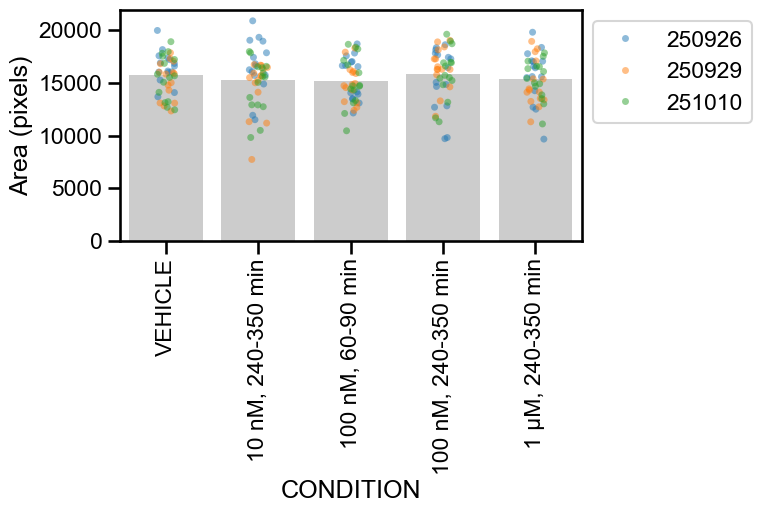

In [14]:
sns.set_context('talk')

f , a = plt.subplots(ncols = 1, figsize = (9,3))

sns.stripplot(mClover_On_DF, x = 'CONDITION', hue = 'DATE', y = 'AREA', ax = a, size = 5, alpha = 0.5)

sns.barplot(mClover_On_DF, x = 'CONDITION', y = 'AREA', ax = a, alpha = 0.2, errorbar = None, color = 'black')



xlabels = a.get_xticklabels()

a.set_xticklabels(xlabels, rotation=90)

a.set_box_aspect(0.5)

a.set_ylabel('Area (pixels)')

a.legend(bbox_to_anchor = (1,1))

plt.tight_layout()

In [15]:
HundredVals = mClover_On_DF.query('CONDITION == "VEHICLE"').drop(['FILE','CONDITION'], axis = 1).groupby(['DATE']).mean().reset_index()

In [16]:
HundredVals

,DATE,AREA,INTENSITY_MCLOVER
0,250926,16525.200000,22.455596
1,250929,15211.600000,21.134819
2,251010,15596.533333,19.252892


In [17]:
def norm_int_byday(d,i):
    h = HundredVals[HundredVals['DATE'] == d].INTENSITY_MCLOVER.values[0]
    nv = 100*(i-mClover_Fixed_ZeroValue)/(h-mClover_Fixed_ZeroValue)
    return nv

In [18]:
mClover_On_DF['INTENSITY_MCLOVER_NORM'] = mClover_On_DF.apply(lambda x: norm_int_byday(x.DATE, x.INTENSITY_MCLOVER), axis = 1)

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_57008/28912362.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  a.set_xticklabels(xlabels, rotation=90)
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_57008/28912362.py:19: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


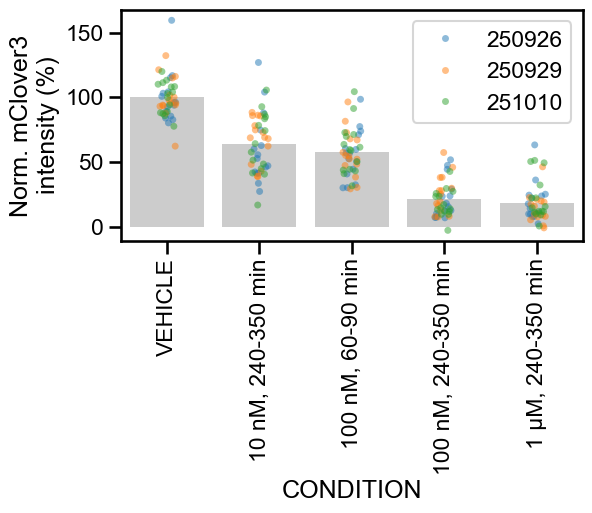

In [19]:
sns.set_context('talk')

f , a = plt.subplots(ncols = 1, figsize = (9,3))

sns.stripplot(mClover_On_DF, x = 'CONDITION', hue = 'DATE', y = 'INTENSITY_MCLOVER_NORM', ax = a, size = 5, alpha = 0.5)

sns.barplot(mClover_On_DF, x = 'CONDITION', y = 'INTENSITY_MCLOVER_NORM', ax = a, alpha = 0.2, errorbar = None, color = 'black')



xlabels = a.get_xticklabels()

a.set_xticklabels(xlabels, rotation=90)

a.set_box_aspect(0.5)

a.set_ylabel('Norm. mClover3\nintensity (%)')

plt.tight_layout()

## Load FRAP results from file

In [20]:
LS_GREEN = []

for i, n in enumerate(SUBDIRS_GREEN):
    LS_GREEN.append([])
    for x in os.listdir(n):
        if x.endswith("csv"):
            LS_GREEN[i].append(x)

In [21]:
green_dfs = []

for i, n in enumerate(SUBDIRS_GREEN):
    for c in LS_GREEN[i]:
        f = pd.read_csv(n + c)
        
        frame = f.index.tolist()
        t = f['Time::Relative Time!!R'][1:94]
        gfp_c = f['Channel1_R1_IntensityMean::EGFP_R1_IntensityMean!!R'][1:94]
        gfp_b = f['Channel1_R2_IntensityMean::EGFP_R2_IntensityMean!!R'][1:94]
        
        condition = SUBDIRS_GREEN_COND[i]
        well = c[:6]
        
        baseline_c = np.mean(gfp_c[:30])
        baseline_b = np.mean(gfp_b[:30])
        
        gfp_c_n = [100*(i/baseline_c) for i in gfp_c]
        gfp_b_n = [100*(i/baseline_b) for i in gfp_b]
        
        GFP_DF1 = pd.DataFrame({
            'FILE' : np.tile(n+c, len(t)),
            'DATE' : np.tile((n+c)[:6], len(t)),
            'CONDITION' : np.tile(condition, len(t)),
            'FRAME' : range(0,len(t)),
            'TIME' : t,
            'BLEACH' : np.tile('Control', len(t)),
            'INTENSITY' : gfp_c,
            'INTENSITY_PCT' : gfp_c_n })
        
        GFP_DF2 = pd.DataFrame({
            'FILE' : np.tile(n+c, len(t)),
            'DATE' : np.tile((n+c)[:6], len(t)),
            'CONDITION' : np.tile(condition, len(t)),
            'FRAME' : range(0,len(t)),
            'TIME' : t,
            'BLEACH' : np.tile('Bleached', len(t)),
            'INTENSITY' : gfp_b,
            'INTENSITY_PCT' : gfp_b_n })
        
        GFP_DF = pd.concat([GFP_DF1, GFP_DF2])
        
        green_dfs.append(GFP_DF)
        
mClover_Data = pd.concat(green_dfs)

## Plot average of FRAP results, both as raw fluorescence intensity and normalised to pre-bleach baseline

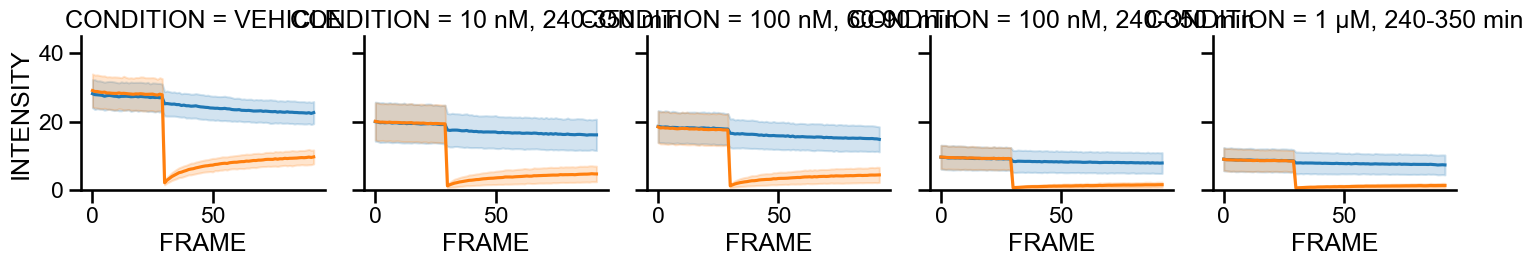

In [22]:
g = sns.FacetGrid(mClover_Data, col = 'CONDITION', ylim = (0,45))

g.map_dataframe(sns.lineplot, x = 'FRAME', y = 'INTENSITY', hue = 'BLEACH', errorbar = 'sd')

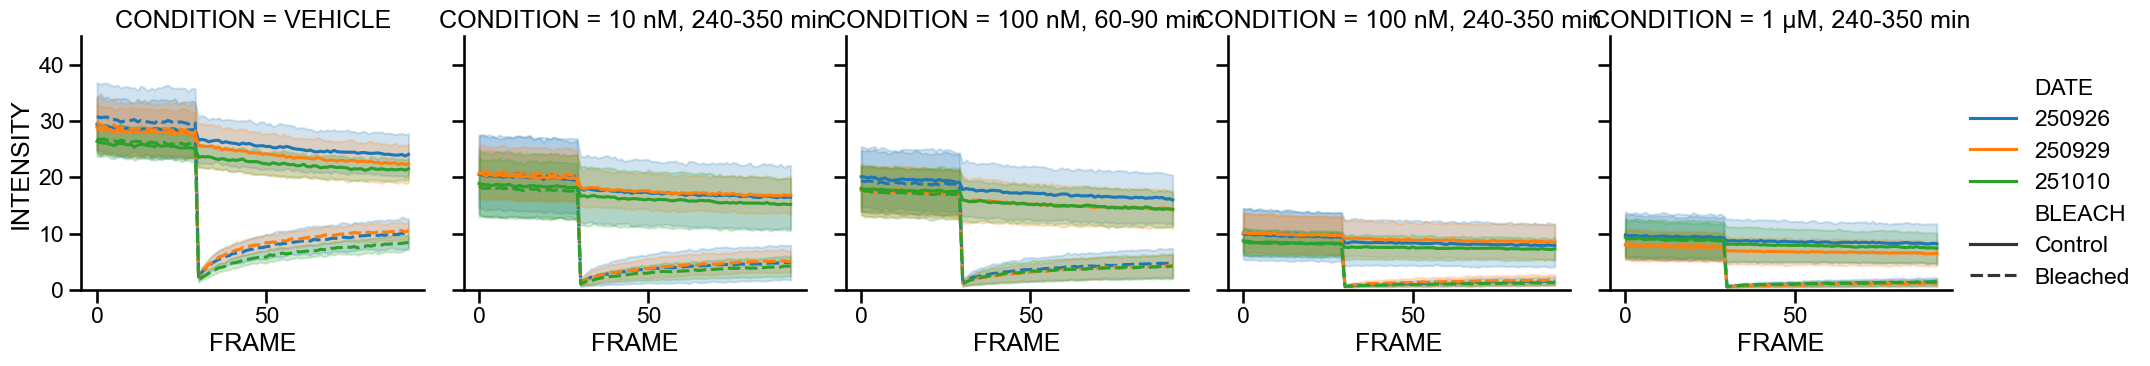

In [23]:
g = sns.FacetGrid(mClover_Data, col = 'CONDITION', ylim = (0,45), height = 4)

g.map_dataframe(sns.lineplot, x = 'FRAME', y = 'INTENSITY', hue = 'DATE', style = 'BLEACH', errorbar = 'sd')
g.add_legend()

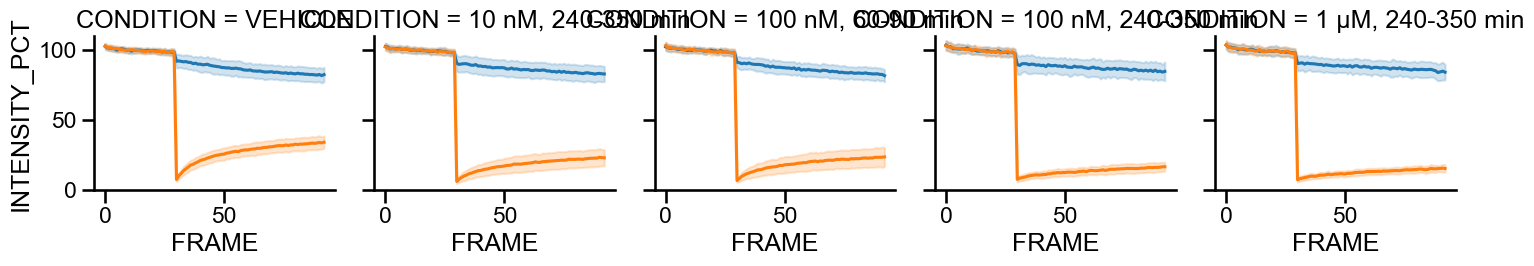

In [24]:
g = sns.FacetGrid(mClover_Data, col = 'CONDITION', ylim = (0,110))

g.map_dataframe(sns.lineplot, x = 'FRAME', y = 'INTENSITY_PCT', hue = 'BLEACH', errorbar = 'sd')

## Plot FRAP data with fixed control overlaid showing 0 value

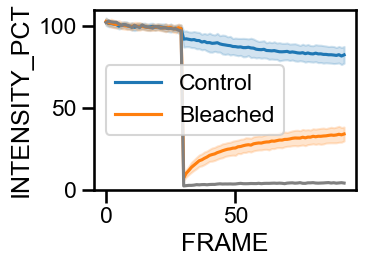

In [25]:
f, a = plt.subplots(ncols = 1, figsize = (4,3))

sns.lineplot(mClover_Data.query('CONDITION == "VEHICLE"'),
             x = 'FRAME',
             y = 'INTENSITY_PCT',
            hue = 'BLEACH',
            errorbar = 'sd',
            ax = a)

sns.lineplot(mClover_Fixed_Data.query('BLEACH == "Bleached"'), 
             x = 'FRAME', 
             y = 'INTENSITY_PCT',
            color = 'grey',
             errorbar = None,
            ax = a)


plt.ylim(0,110)
plt.tight_layout()

## Variation in framerate is negligible

Frame is slightly variable between traces. Check this variation then construct mean time for all traces.

Text(0, 0.5, 'time (ms)')

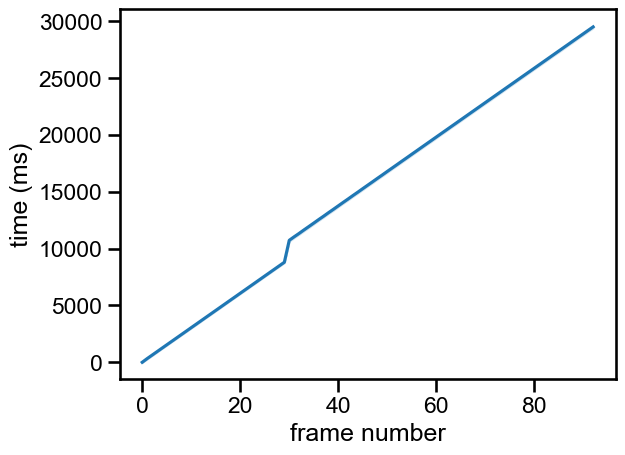

In [26]:
frames = mClover_Data.FRAME.unique()

g = []
h = []

for f in frames:
    l = mClover_Data[mClover_Data.FRAME == f].TIME.astype('float').tolist()
    g.extend(l)
    h.extend(np.tile(f,len(l)))

df = pd.DataFrame({'h' : h, 'g' : g})
sns.lineplot(df, x = h, y = g, errorbar=("pi", 100))

plt.xlabel('frame number')
plt.ylabel('time (ms)')

(0.0, 4000.0)

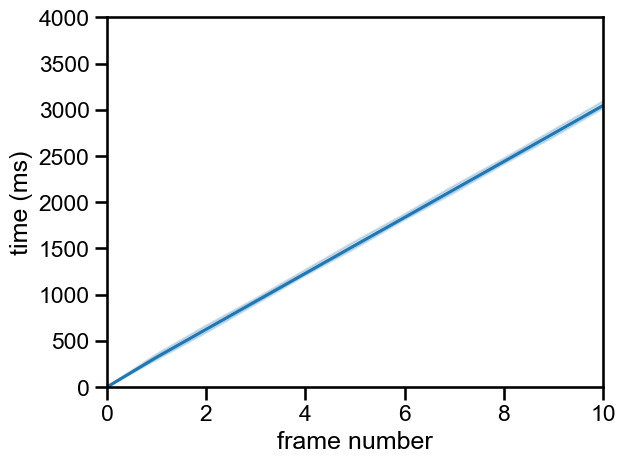

In [27]:
sns.lineplot(df, x = h, y = g, errorbar=("pi", 100))

plt.xlabel('frame number')
plt.ylabel('time (ms)')

plt.xlim(0,10)
plt.ylim(0,4000)

(0.0, 30000.0)

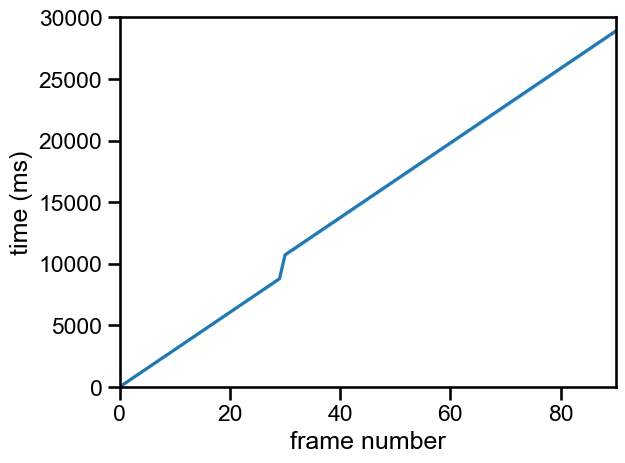

In [28]:
sns.lineplot(df, x = h, y = g, errorbar=("pi", 100))

plt.xlabel('frame number')
plt.ylabel('time (ms)')

plt.xlim(0,90)
plt.ylim(0,30000)

# Normalise FRAP data and plot

## Normalise FRAP traces to unbleached control region and to fixed FRAP traces

In [29]:
frames = mClover_Data.FRAME.unique()
mean_time = []

for f in frames:
    avg = mClover_Data[mClover_Data.FRAME == f].TIME.astype('float').mean()
    mean_time.append(avg)

filename = []
baseline_intensity = []
date = []
condition = []
celltype = []
timer = []
intensities = []


for each in mClover_Data.FILE.unique():
    
    crop = mClover_Data[mClover_Data.FILE == each]
        
    raw = crop[crop.BLEACH == 'Bleached'].INTENSITY
    baseline = np.mean(raw[:30])
    
    ints = crop[crop.BLEACH == 'Bleached'].INTENSITY_PCT
    hunds = crop[crop.BLEACH == 'Control'].INTENSITY_PCT
    
    cond = mClover_Data[mClover_Data.FILE == each].CONDITION.unique()[0]
    
    zero_val = mClover_Fixed_ZeroValue
    
    ints_zerod = [i - zero_val for i in ints]
    hunds_zerod = [i - zero_val for i in hunds]
    
    ints_norm = [100*(i/h) for i,h in zip(ints_zerod, hunds_zerod)]
    
    lngth = len(ints_norm)
    
    filename.extend(np.tile(each,lngth))
    baseline_intensity.extend(np.tile(baseline,lngth))
    date.extend((np.tile(each[:6],lngth)))
    condition.extend(np.tile(cond,lngth))
    intensities.extend(ints_norm)
    timer.extend(mean_time[:lngth])
    
    
mClover_Normalised_Data = pd.DataFrame({
"FILE" : filename,
"DATE" : date,
"CONDITION" : condition,
"TIME" : timer,
"INTENSITY_NORMED" : intensities,
"BASELINE_INTENSITY" : baseline_intensity})

## Plot normalised FRAP traces across days, and per experimental day

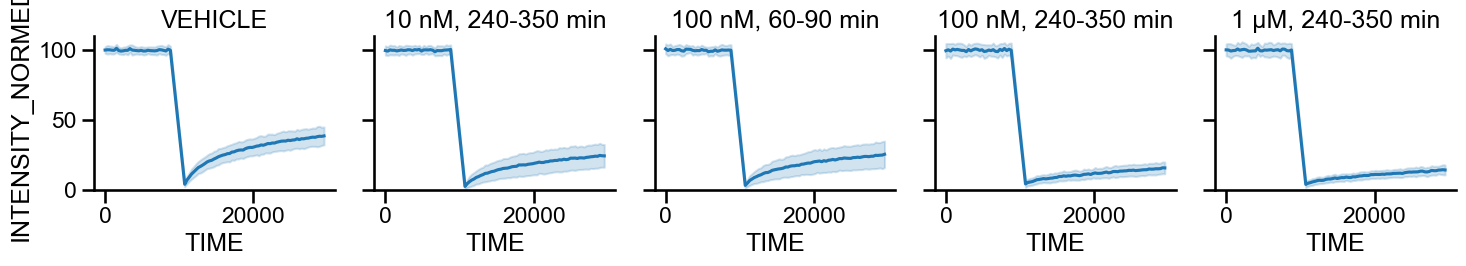

In [30]:
g = sns.FacetGrid(mClover_Normalised_Data, col = 'CONDITION', ylim = (0,110))

g.map_dataframe(sns.lineplot, x = 'TIME', y = 'INTENSITY_NORMED', errorbar = 'sd')

g.set_titles(col_template="{col_name}")

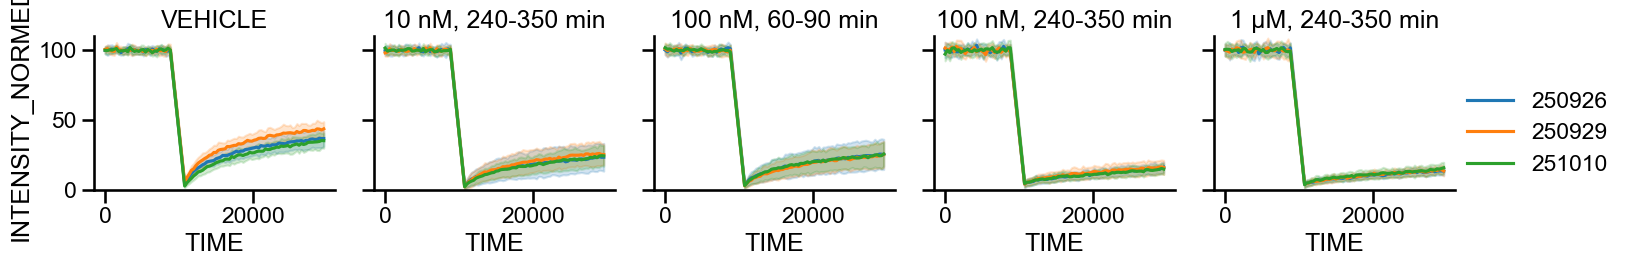

In [31]:
g = sns.FacetGrid(mClover_Normalised_Data, col = 'CONDITION', ylim = (0,110))

g.map_dataframe(sns.lineplot, x = 'TIME', y = 'INTENSITY_NORMED', hue = 'DATE', errorbar = 'sd')

g.add_legend()

g.set_titles(col_template="{col_name}")

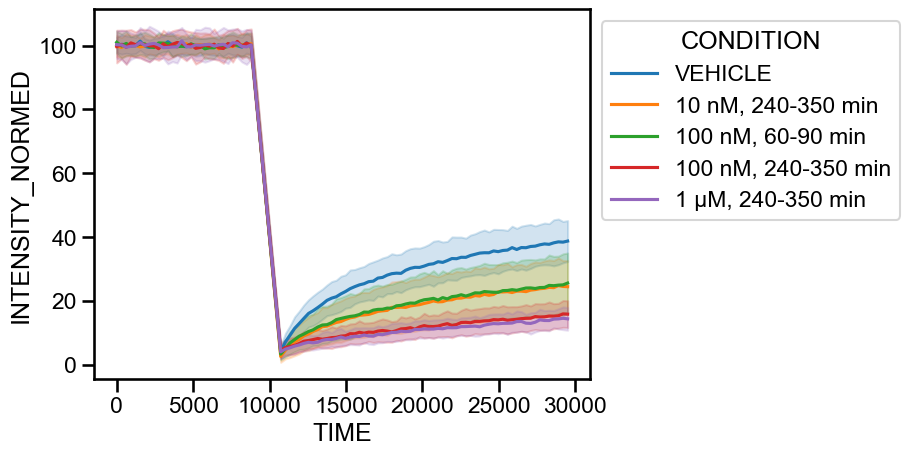

In [32]:
h = sns.lineplot(mClover_Normalised_Data, x = 'TIME', y = 'INTENSITY_NORMED', hue = 'CONDITION', errorbar = 'sd')

sns.move_legend(h, 'upper left', bbox_to_anchor = (1,1))

In [33]:
mClover_Normalised_Data.CONDITION.unique()

array(['VEHICLE', '10 nM, 240-350 min', '100 nM, 60-90 min',
       '100 nM, 240-350 min', '1 µM, 240-350 min'], dtype=object)

<Axes: xlabel='TIME', ylabel='INTENSITY_NORMED'>

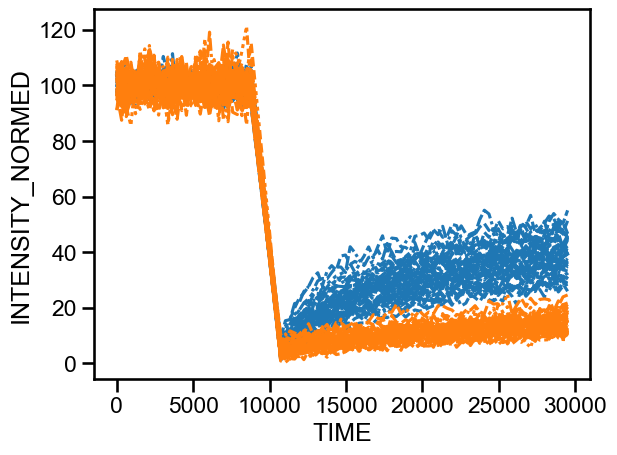

In [34]:
sns.lineplot(mClover_Normalised_Data.query('CONDITION == "VEHICLE" | CONDITION == "1 µM, 240-350 min"'),
             x = 'TIME', 
             y = 'INTENSITY_NORMED', 
             hue = 'CONDITION', 
             style = 'FILE',
             legend = False)

# Compare intensity value at last timepoint to check recovery after photobleaching without fitting

In [35]:
lasttime = mClover_Normalised_Data.TIME.max()

In [36]:
RecoveredValuemClover = mClover_Normalised_Data[mClover_Normalised_Data['TIME'] == lasttime]
RecoveredValuemCloverByDay = RecoveredValuemClover.drop(['FILE','TIME'], axis = 1).groupby(['DATE', 'CONDITION']).mean().reset_index()

In [37]:
RecoveredValuemClover.CONDITION.unique()

array(['VEHICLE', '10 nM, 240-350 min', '100 nM, 60-90 min',
       '100 nM, 240-350 min', '1 µM, 240-350 min'], dtype=object)

Text(31.58333333333333, 0.5, 'Recovered fluorescence\n(mobile fraction)')

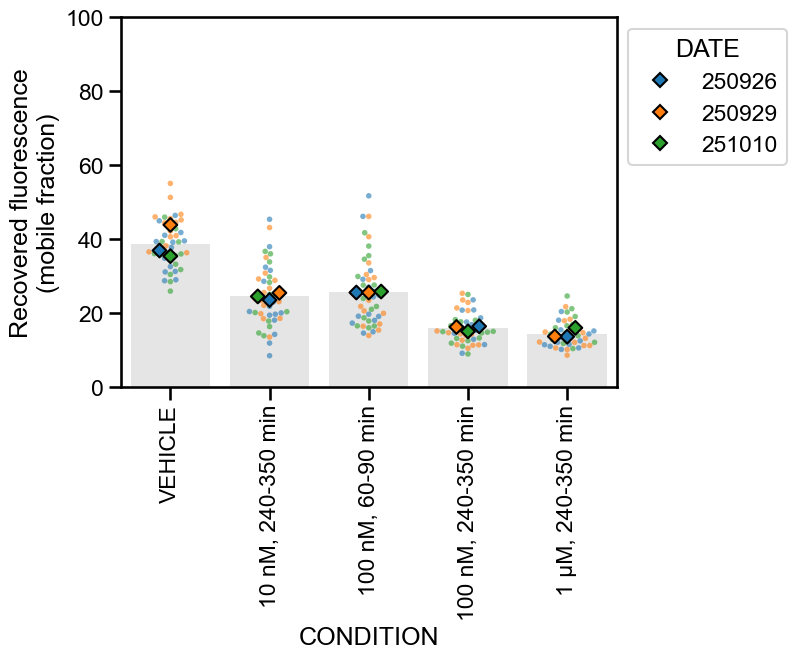

In [38]:
sns.barplot(RecoveredValuemCloverByDay, 
            x = 'CONDITION', order = condition_order,
            y = 'INTENSITY_NORMED', 
            alpha = 0.1, 
            color = 'black', 
            errorbar = None)

i = sns.swarmplot(RecoveredValuemClover, 
              x = 'CONDITION', order = condition_order,
              y = 'INTENSITY_NORMED', 
              hue = 'DATE', 
              size = 4, 
                  alpha = 0.6,
                 legend = False)

h = sns.swarmplot(RecoveredValuemCloverByDay, 
              x = 'CONDITION', order = condition_order,
              y = 'INTENSITY_NORMED',
                  marker = 'D', edgecolor="black", linewidth = 1.5,
              size = 7, hue = 'DATE')



sns.move_legend(h, 'upper left', bbox_to_anchor = (1,1))
plt.ylim(0,100)
plt.xticks(rotation = 90);

plt.ylabel('Recovered fluorescence\n(mobile fraction)')

In [39]:
RecoveredValuemClover.drop(['FILE','TIME','DATE'], axis = 1).groupby(['CONDITION']).mean().reset_index()

,CONDITION,INTENSITY_NORMED,BASELINE_INTENSITY
0,"1 µM, 240-350 min",14.392008,8.686959
1,"10 nM, 240-350 min",24.464116,19.675602
2,"100 nM, 240-350 min",15.862218,9.368017
3,"100 nM, 60-90 min",25.604254,17.910179
4,VEHICLE,38.760727,28.372232


In [40]:
RecoveredValuemClover.drop(['FILE','TIME','DATE'], axis = 1).groupby(['CONDITION']).std().reset_index()

,CONDITION,INTENSITY_NORMED,BASELINE_INTENSITY
0,"1 µM, 240-350 min",3.563538,3.166641
1,"10 nM, 240-350 min",8.184876,5.455281
2,"100 nM, 240-350 min",4.190523,3.310945
3,"100 nM, 60-90 min",9.415411,4.642224
4,VEHICLE,6.417633,4.769841


# Fitting FRAP data to single exponential recovery curve

In [41]:
# define exponential curve

def MonoEx(x, A, B):
    return A * (1- np.exp(-B * x))

## fit per day

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_57008/2471684709.py:4: RuntimeWarning: overflow encountered in exp
  return A * (1- np.exp(-B * x))
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_57008/2471684709.py:4: RuntimeWarning: overflow encountered in multiply
  return A * (1- np.exp(-B * x))
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_57008/2471684709.py:4: RuntimeWarning: overflow encountered in exp
  return A * (1- np.exp(-B * x))
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_57008/2471684709.py:4: RuntimeWarning: overflow encountered in exp
  return A * (1- np.exp(-B * x))
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_57008/2471684709.py:4: RuntimeWarning: overflow encountered in exp
  return A * (1- np.exp(-B * x))
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_57008/2471684709.py:4: RuntimeWarning: overflow encountered in exp
  return A * (1- np.exp(-B * x))
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00

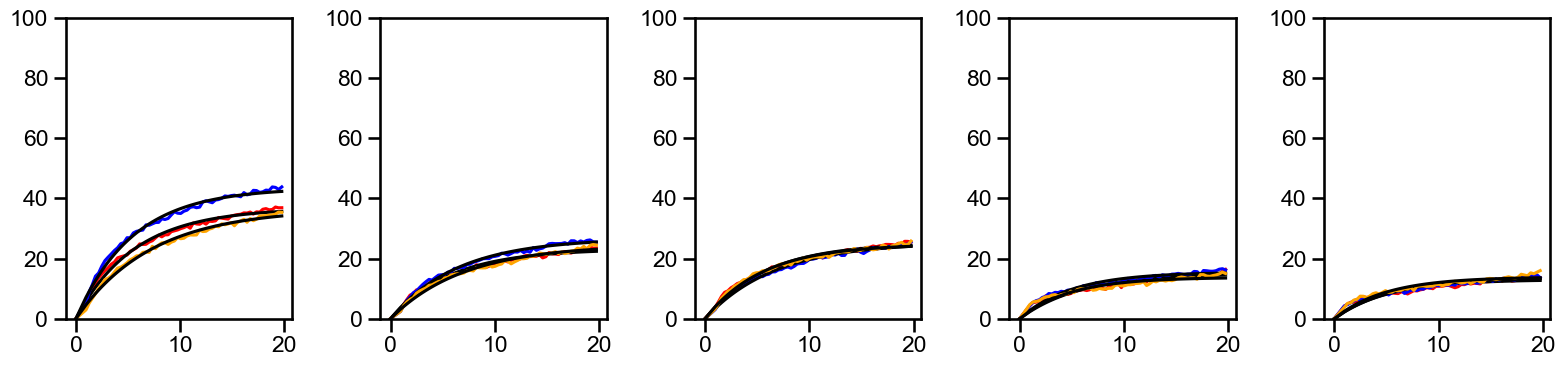

In [42]:
f , a = plt.subplots(ncols = len(condition_order), figsize = (16,4))

colours = ['red', 'blue', 'orange']

for col,c in enumerate(mClover_Normalised_Data.CONDITION.unique()):
    for h,d in enumerate(mClover_Normalised_Data.DATE.unique()):
        
        frame = mClover_Normalised_Data[
            (mClover_Normalised_Data['CONDITION'] == c) & (mClover_Normalised_Data['DATE'] == d)].drop(['CONDITION','FILE','DATE'], axis = 1)
        
        frame = frame.groupby('TIME').mean().reset_index()
        
        xs = frame.TIME.tolist()
        ys = frame.INTENSITY_NORMED.tolist()
        
        zero_time =  xs[29] + (xs[30] - xs[29])/2
        
        xs = xs[30:]
        ys = ys[30:]

        xs = [(i-zero_time)/1000 for i in xs]

        xs = np.insert(xs,0,0)
        ys = np.insert(ys,0,0)
        
        popt, pcov = optimize.curve_fit(MonoEx, xs, ys, p0=[50, 5])
        plat = popt[0]
        tau = popt[1]
        
        sns.lineplot(x = xs, y = ys, ax = a[col], color = colours[h])
        sns.lineplot(x = xs, y = [MonoEx(i, plat, tau) for i in xs], ax = a[col], color = 'black')
        a[col].set_ylim(0,100)
        
plt.tight_layout()

In [43]:
conditions = []
dates = []
taus = []
plats = []
baselines = []

for c in mClover_Normalised_Data.CONDITION.unique():
    for d in mClover_Normalised_Data.DATE.unique():
        
        frame = mClover_Normalised_Data[
            (mClover_Normalised_Data['CONDITION'] == c) & (mClover_Normalised_Data['DATE'] == d)].drop(['CONDITION','FILE','DATE'], axis = 1)
        
        frame = frame.groupby('TIME').mean().reset_index()
        
        xs = frame.TIME.tolist()
        ys = frame.INTENSITY_NORMED.tolist()
        
        zero_time =  xs[29] + (xs[30] - xs[29])/2
        
        xs = xs[30:]
        ys = ys[30:]

        xs = [(i-zero_time)/1000 for i in xs]

        xs = np.insert(xs,0,0)
        ys = np.insert(ys,0,0)
        
        popt, pcov = optimize.curve_fit(MonoEx, xs, ys, p0=[50, 5])
        plat = popt[0]
        tau = popt[1]
        
        bl = frame.BASELINE_INTENSITY.unique()[0]
        
        conditions.append(c)
        dates.append(d)
        taus.append(tau)
        plats.append(plat)
        baselines.append(bl)
        
mCloverFittingPerDay = pd.DataFrame({
    'CONDITION' : conditions,
    'DATE' : dates,
    'TAU' : taus,
    'PLATEAU' : plats,
    'BASELINE_INTENSITY' : baselines})

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_57008/2471684709.py:4: RuntimeWarning: overflow encountered in exp
  return A * (1- np.exp(-B * x))
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_57008/2471684709.py:4: RuntimeWarning: overflow encountered in multiply
  return A * (1- np.exp(-B * x))
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_57008/2471684709.py:4: RuntimeWarning: overflow encountered in exp
  return A * (1- np.exp(-B * x))
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_57008/2471684709.py:4: RuntimeWarning: overflow encountered in exp
  return A * (1- np.exp(-B * x))
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_57008/2471684709.py:4: RuntimeWarning: overflow encountered in exp
  return A * (1- np.exp(-B * x))
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_57008/2471684709.py:4: RuntimeWarning: overflow encountered in exp
  return A * (1- np.exp(-B * x))
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00

## fit per cell

In [44]:
files = []
conditions = []
dates = []
taus = []
plats = []
baseline_intensity = []

for f in mClover_Normalised_Data.FILE.unique():
        
        frame = mClover_Normalised_Data[(mClover_Normalised_Data['FILE'] == f)]
        
        c = frame.CONDITION.unique()[0]
        d = frame.DATE.unique()[0]
        bl = frame.BASELINE_INTENSITY.unique()[0]
        
        xs = frame.TIME.tolist()
        ys = frame.INTENSITY_NORMED.tolist()
        
        zero_time =  xs[29] + (xs[30] - xs[29])/2
        
        xs = xs[30:]
        ys = ys[30:]

        xs = [(i-zero_time)/1000 for i in xs]

        xs = np.insert(xs,0,0)
        ys = np.insert(ys,0,0)
        
        popt, pcov = optimize.curve_fit(MonoEx, xs, ys, p0=[50, 5])
        plat = popt[0]
        tau = popt[1]
        
        files.append(f)
        conditions.append(c)
        dates.append(d)
        taus.append(tau)
        plats.append(plat)
        baseline_intensity.append(bl)
        
mCloverFittingPerCell = pd.DataFrame({
    'FILE' : files,
    'CONDITION' : conditions,
    'DATE' : dates,
    'TAU' : taus,
    'PLATEAU' : plats,
    'BASELINE_INTENSITY' : baseline_intensity})

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_57008/2471684709.py:4: RuntimeWarning: overflow encountered in exp
  return A * (1- np.exp(-B * x))
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_57008/2471684709.py:4: RuntimeWarning: overflow encountered in multiply
  return A * (1- np.exp(-B * x))


## Show results for both plateau and rate of exponential fit, fitted per day and per cell

/Users/alexandergillis/opt/anaconda3/envs/pyimg310/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 11.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/alexandergillis/opt/anaconda3/envs/pyimg310/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 11.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/alexandergillis/opt/anaconda3/envs/pyimg310/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 22.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/alexandergillis/opt/anaconda3/envs/pyimg310/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 31.1% of the points cannot be placed; you may want to decrease the size of the markers or use s

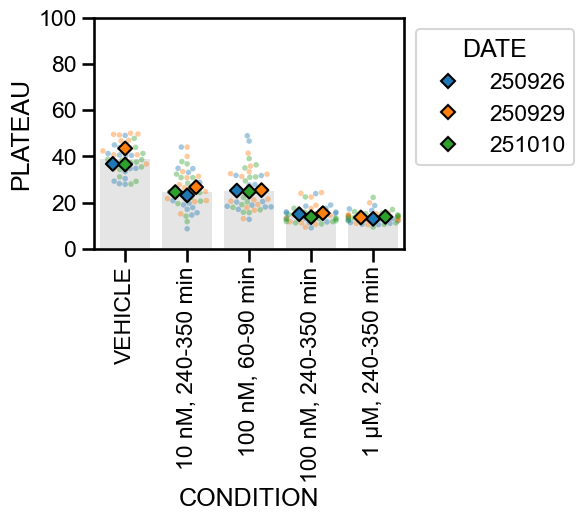

In [45]:
f, a = plt.subplots(figsize = (4,3))

sns.barplot(mCloverFittingPerDay, 
            x = 'CONDITION', order = condition_order,
            y = 'PLATEAU', alpha = 0.1, color = 'black', errorbar = None)

i = sns.swarmplot(mCloverFittingPerCell, 
              x = 'CONDITION', order = condition_order,
              y = 'PLATEAU', 
              hue = 'DATE', 
              size = 4, alpha = 0.4,
                 legend = False)

h = sns.swarmplot(mCloverFittingPerDay, 
              x = 'CONDITION', order = condition_order,
              y = 'PLATEAU',
                  marker = 'D', edgecolor="black", linewidth = 1.5,
              size = 7, hue = 'DATE')



sns.move_legend(h, 'upper left', bbox_to_anchor = (1,1))
plt.ylim(0,100)
plt.xticks(rotation = 90);

/Users/alexandergillis/opt/anaconda3/envs/pyimg310/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 11.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/alexandergillis/opt/anaconda3/envs/pyimg310/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 6.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/alexandergillis/opt/anaconda3/envs/pyimg310/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 11.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/alexandergillis/opt/anaconda3/envs/pyimg310/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 6.7% of the points cannot be placed; you may want to decrease the size of the markers or use str

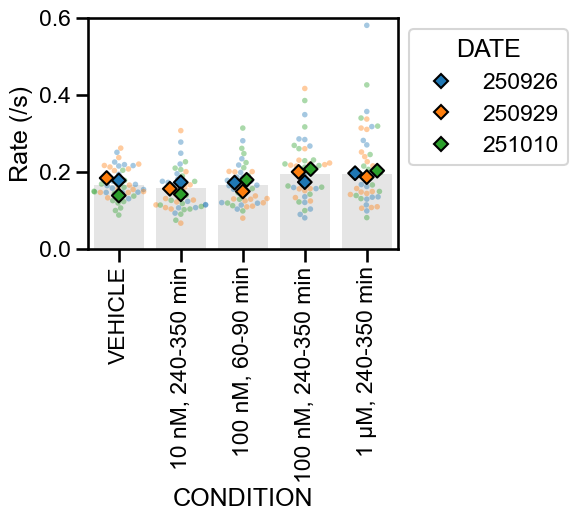

In [46]:
f, a = plt.subplots(figsize = (4,3))

sns.barplot(mCloverFittingPerDay, 
            x = 'CONDITION', order = condition_order,
            y = 'TAU', alpha = 0.1, color = 'black', errorbar = None)

i = sns.swarmplot(mCloverFittingPerCell, 
              x = 'CONDITION', order = condition_order,
              y = 'TAU', 
              hue = 'DATE', 
              size = 4, alpha = 0.4,
                 legend = False)

h = sns.swarmplot(mCloverFittingPerDay, 
              x = 'CONDITION', order = condition_order,
              y = 'TAU',
                  marker = 'D', edgecolor="black", linewidth = 1.5,
              size = 7, hue = 'DATE')


plt.ylabel('Rate (/s)')
sns.move_legend(h, 'upper left', bbox_to_anchor = (1,1))
plt.ylim(0,0.6)
plt.xticks(rotation = 90);

# Use baseline fluorescence intensity to calculate relative total Pol II amounts

In [47]:
dates = []
conditions = []
amount_bound = []
amount_free = []
totals = []

for d in mCloverFittingPerDay.DATE.unique():
    crop = mCloverFittingPerDay[ mCloverFittingPerDay['DATE'] == d ]
    HundredPct = crop[ crop['CONDITION'] == 'VEHICLE' ]['BASELINE_INTENSITY'].tolist()[0]
    
    for c in crop.CONDITION.unique():
        crop2 = crop[ crop['CONDITION'] == c ]
        
        relative_total = (crop2['BASELINE_INTENSITY'].tolist()[0]/HundredPct)
        plat = crop2['PLATEAU'].tolist()[0]
        
        free = (plat/100)*relative_total
        bound = relative_total - free
        
        dates.append(d)
        conditions.append(c)
        amount_bound.append(100*bound)
        amount_free.append(100*free)
        totals.append(100*relative_total)
        
mCloverPolAmountsPerDay = pd.DataFrame({
'DATE' :dates,
'CONDITION' :conditions,
'RELATIVE_TOTAL' : totals,
'BOUND' : amount_bound,
'FREE' : amount_free})

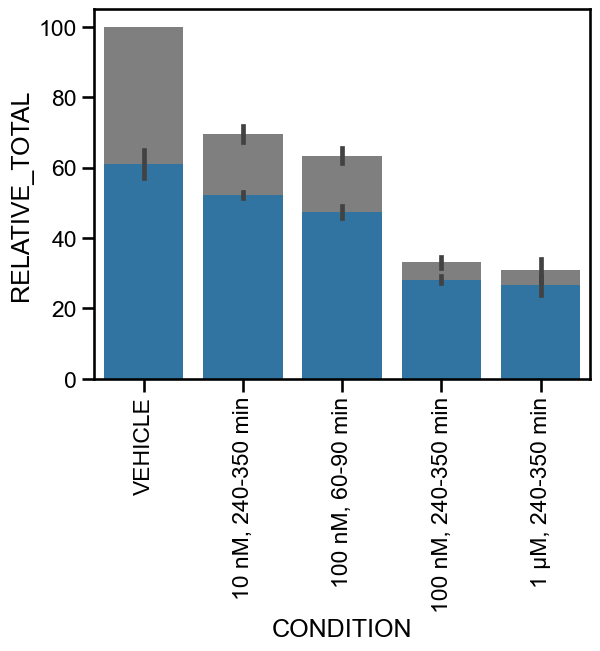

In [48]:
sns.barplot(mCloverPolAmountsPerDay, 
            x = 'CONDITION', order = condition_order,
            y = 'RELATIVE_TOTAL', 
            color = 'black', 
            alpha = 0.5,
           errorbar = ('sd'))

sns.barplot(mCloverPolAmountsPerDay, 
            x = 'CONDITION', order = condition_order,
            y = 'BOUND',
           errorbar = ('sd'))

plt.xticks(rotation = 90);

In [49]:
files = []
conditions = []
amount_bound = []
amount_free = []
totals = []

for f in mCloverFittingPerCell.FILE.unique():
    crop = mCloverFittingPerCell[ mCloverFittingPerCell['FILE'] == f ]
    
    c = crop.CONDITION.unique()[0]
    
    HundredPct = mCloverFittingPerCell[ mCloverFittingPerCell['CONDITION'] == 'VEHICLE' ]['BASELINE_INTENSITY'].mean()

    relative_total = (crop['BASELINE_INTENSITY'].tolist()[0]/HundredPct)
    plat = crop['PLATEAU'].tolist()[0]

    free = (plat/100)*relative_total
    bound = relative_total - free

    files.append(f)
    conditions.append(c)
    amount_bound.append(100*bound)
    amount_free.append(100*free)
    totals.append(100*relative_total)
    
    
mCloverPolAmountsPerCell = pd.DataFrame({
'FILE' :files,
'CONDITION' :conditions,
'RELATIVE_TOTAL' : totals,
'BOUND' : amount_bound,
'FREE' : amount_free})

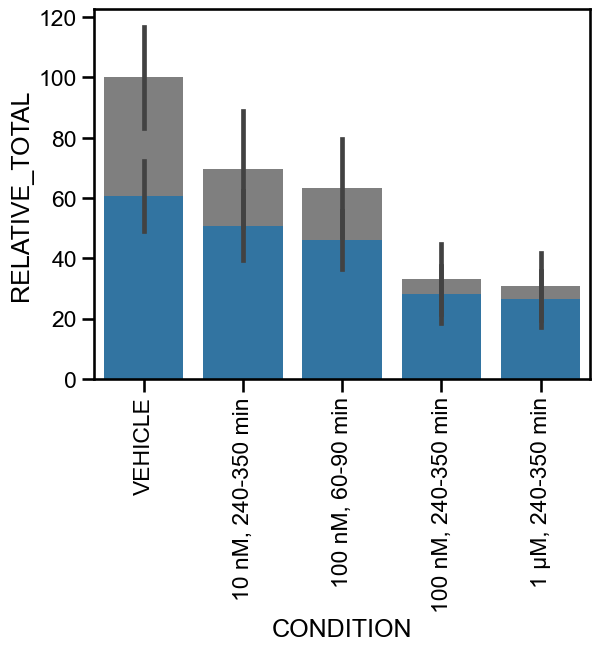

In [50]:
sns.barplot(mCloverPolAmountsPerCell, 
            x = 'CONDITION', order = condition_order,
            y = 'RELATIVE_TOTAL', 
            color = 'black', 
            alpha = 0.5,
           errorbar = 'sd')
sns.barplot(mCloverPolAmountsPerCell, order = condition_order,
            x = 'CONDITION', 
            y = 'BOUND', 
            errorbar = 'sd')

plt.xticks(rotation = 90);

# Plot FRAP and fitting results for manuscript

In [51]:
mClover_Normalised_Data['TIME_S'] = mClover_Normalised_Data['TIME']/1000

In [52]:
mClover_Normalised_Data.CONDITION.unique()

array(['VEHICLE', '10 nM, 240-350 min', '100 nM, 60-90 min',
       '100 nM, 240-350 min', '1 µM, 240-350 min'], dtype=object)

In [53]:
sns.color_palette('deep')[3]

(0.7686274509803922, 0.3058823529411765, 0.3215686274509804)

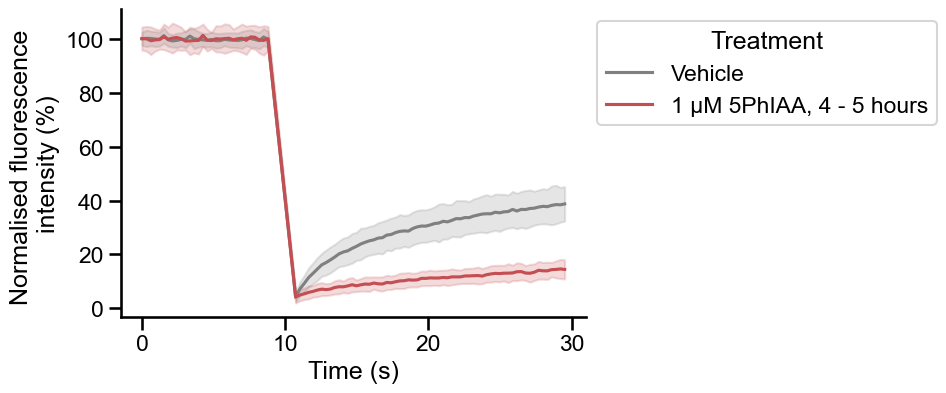

In [54]:
f, a = plt.subplots(nrows = 1, figsize = (6,4))

sns.set_context('talk')

cp = sns.color_palette(['grey',sns.color_palette('deep')[3]])

g = sns.lineplot(mClover_Normalised_Data.query('CONDITION == "VEHICLE" | CONDITION == "1 µM, 240-350 min"'), 
             hue = 'CONDITION', 
             x = 'TIME_S', 
             y = 'INTENSITY_NORMED',
                 palette = cp,
                 errorbar = 'sd',
                ax = a)

sns.move_legend(g, 'upper left', bbox_to_anchor = (1,1))

legend_handles, _= a.get_legend_handles_labels()
a.legend(legend_handles, ['Vehicle','1 µM 5PhIAA, 4 - 5 hours'], 
          bbox_to_anchor=(1,1), 
          title='Treatment')

a.set_xlabel('Time (s)')
a.set_ylabel('Normalised fluorescence \nintensity (%)')

sns.despine()

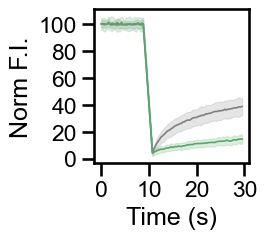

In [55]:
f, a = plt.subplots(nrows = 1, figsize = (2,2))

sns.set_context('paper')

cp = sns.color_palette(['grey',sns.color_palette('deep')[2]])

g = sns.lineplot(mClover_Normalised_Data.query('CONDITION == "VEHICLE" | CONDITION == "1 µM, 240-350 min"'), 
             hue = 'CONDITION', 
             x = 'TIME_S', 
             y = 'INTENSITY_NORMED',
                 palette = cp,
                 errorbar = 'sd',
                ax = a,
                legend = False)


a.set_xlabel('Time (s)')
a.set_ylabel('Norm F.I.')

plt.savefig('mACPOLR2A_FRAP_Veh_1uM.svg')

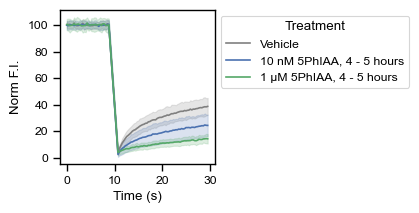

In [56]:
f, a = plt.subplots(nrows = 1, figsize = (2,2))

sns.set_context('paper')

cp = sns.color_palette(['grey',sns.color_palette('deep')[0],sns.color_palette('deep')[2]])

g = sns.lineplot(mClover_Normalised_Data.query('CONDITION == "VEHICLE" | CONDITION == "10 nM, 240-350 min" | CONDITION == "1 µM, 240-350 min"'), 
             hue = 'CONDITION', 
             x = 'TIME_S', 
             y = 'INTENSITY_NORMED',
                 palette = cp,
                 errorbar = 'sd',
                ax = a)

sns.move_legend(g, 'upper left', bbox_to_anchor = (1,1))

legend_handles, _= a.get_legend_handles_labels()
a.legend(legend_handles, ['Vehicle', '10 nM 5PhIAA, 4 - 5 hours', '1 µM 5PhIAA, 4 - 5 hours'], 
          bbox_to_anchor=(1,1), 
          title='Treatment')

a.set_xlabel('Time (s)')
a.set_ylabel('Norm F.I.')

plt.savefig('mACPOLR2A_FRAP_Veh_1uM_10nM.svg')

In [57]:
condition_order[0],condition_order[1],condition_order[4]

('VEHICLE', '10 nM, 240-350 min', '1 µM, 240-350 min')

In [58]:
mCloverPolAmountsPerDay.query('CONDITION == "VEHICLE" | CONDITION == "10 nM, 240-350 min" | CONDITION == "1 µM, 240-350 min"')

,DATE,CONDITION,RELATIVE_TOTAL,BOUND,FREE
0,250926,VEHICLE,100.000000,63.232148,36.767852
1,250926,"10 nM, 240-350 min",68.419235,52.570705,15.848530
4,250926,"1 µM, 240-350 min",30.750822,26.760509,3.990313
5,250929,VEHICLE,100.000000,56.529400,43.470600
6,250929,"10 nM, 240-350 min",72.064638,52.817111,19.247527
9,250929,"1 µM, 240-350 min",27.647603,23.894133,3.753469
10,251010,VEHICLE,100.000000,63.478942,36.521058
11,251010,"10 nM, 240-350 min",68.081317,51.353062,16.728255
14,251010,"1 µM, 240-350 min",33.988861,29.280886,4.707975


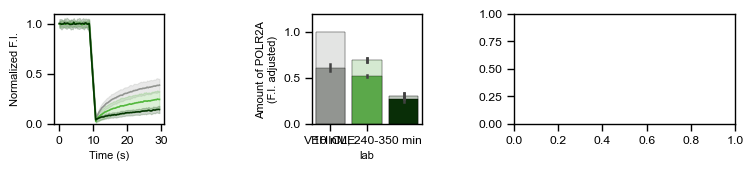

In [59]:
f, a = plt.subplots(ncols = 3, figsize = (8,1.8))

sns.set_context('paper')

cp = sns.color_palette(['xkcd:grey','xkcd:leafy green','xkcd:dark green'])

mClover_Normalised_Data['INTENSITY_NORMED_FC'] = mClover_Normalised_Data['INTENSITY_NORMED'] / 100

g = sns.lineplot(mClover_Normalised_Data.query('CONDITION == "VEHICLE" | CONDITION == "10 nM, 240-350 min" | CONDITION == "1 µM, 240-350 min"'), 
             hue = 'CONDITION', 
             x = 'TIME_S', 
             y = 'INTENSITY_NORMED_FC',
                 palette = cp,
                 errorbar = 'sd',
                ax = a[0],
                 legend = False)

a[0].set_box_aspect(1)

a[0].set_yticks([0,0.5,1])
a[0].set_ylim(0,1.1)

a[0].set_xticks([0,10,20,30])

a[0].set_xlabel('Time (s)', fontsize = 8)
a[0].set_ylabel('Normalized F.I.', fontsize = 8)


mCloverPolAmountsPerDay['RELATIVE_TOTAL_FC'] = mCloverPolAmountsPerDay['RELATIVE_TOTAL'] / 100
mCloverPolAmountsPerDay['BOUND_FC'] = mCloverPolAmountsPerDay['BOUND'] / 100


sns.barplot(mCloverPolAmountsPerDay.query('CONDITION == "VEHICLE" | CONDITION == "10 nM, 240-350 min" | CONDITION == "1 µM, 240-350 min"'), 
            x = 'CONDITION', order = [condition_order[0],condition_order[1],condition_order[4]],
            color = 'white',
            y = 'RELATIVE_TOTAL_FC',  

           errorbar = 'sd',
            edgecolor = 'black',
            linewidth = 0.25,
            ax = a[1])

sns.barplot(mCloverPolAmountsPerDay.query('CONDITION == "VEHICLE" | CONDITION == "10 nM, 240-350 min" | CONDITION == "1 µM, 240-350 min"'), 
            x = 'CONDITION', order = [condition_order[0],condition_order[1],condition_order[4]],
            hue = 'CONDITION', hue_order = [condition_order[0],condition_order[1],condition_order[4]], palette = cp,
            y = 'RELATIVE_TOTAL_FC',  
            alpha = 0.25,
           errorbar = 'sd',
            edgecolor = 'black',
            linewidth = 0.25,
            ax = a[1])



sns.barplot(mCloverPolAmountsPerDay.query('CONDITION == "VEHICLE" | CONDITION == "10 nM, 240-350 min" | CONDITION == "1 µM, 240-350 min"'), 
            x = 'CONDITION', order = [condition_order[0],condition_order[1],condition_order[4]],
            hue = 'CONDITION', hue_order = [condition_order[0],condition_order[1],condition_order[4]],
            palette = cp,
            y = 'BOUND_FC', 
            errorbar = 'sd',
            edgecolor = 'black',
            linewidth = 0.25,
            ax = a[1])


a[1].set_ylim(0,1.2)

a[1].set_ylabel('Amount of POLR2A \n(F.I. adjusted)', fontsize = 8)
a[1].set_xlabel('lab', fontsize = 8)
a[1].set_xticks([0,1])

a[1].set_box_aspect(1)

plt.tight_layout()

plt.savefig('mACPOLR2A_FRAP_Veh_1uM_10nM_fc.svg')

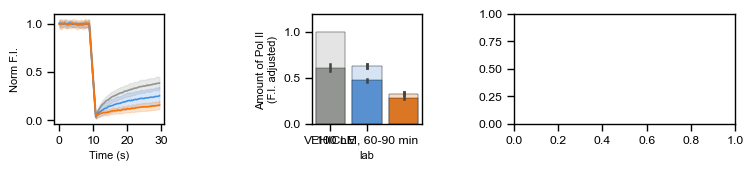

In [60]:
f, a = plt.subplots(ncols = 3, figsize = (8,1.8))

sns.set_context('paper')

cp = sns.color_palette(['xkcd:grey','xkcd:dark sky blue','xkcd:orange'])


g = sns.lineplot(mClover_Normalised_Data.query('CONDITION == "VEHICLE" | CONDITION == "100 nM, 60-90 min" | CONDITION == "100 nM, 240-350 min"'), 
             hue = 'CONDITION', 
             x = 'TIME_S', 
             y = 'INTENSITY_NORMED_FC',
                 palette = cp,
                 errorbar = 'sd',
                ax = a[0],
                 legend = False)

a[0].set_box_aspect(1)

a[0].set_yticks([0,0.5,1])

a[0].set_xticks([0,10,20,30])

a[0].set_xlabel('Time (s)', fontsize = 8)
a[0].set_ylabel('Norm F.I.', fontsize = 8)

sns.barplot(mCloverPolAmountsPerDay.query('CONDITION == "VEHICLE" | CONDITION == "100 nM, 60-90 min" | CONDITION == "100 nM, 240-350 min"'), 
            x = 'CONDITION',
            color = 'white',
            y = 'RELATIVE_TOTAL_FC',  

           errorbar = 'sd',
            edgecolor = 'black',
            linewidth = 0.25,
            ax = a[1])

sns.barplot(mCloverPolAmountsPerDay.query('CONDITION == "VEHICLE" | CONDITION == "100 nM, 60-90 min" | CONDITION == "100 nM, 240-350 min"'), 
            x = 'CONDITION', 
            hue = 'CONDITION', palette = cp,
            y = 'RELATIVE_TOTAL_FC',  
            alpha = 0.25,
           errorbar = 'sd',
            edgecolor = 'black',
            linewidth = 0.25,
            ax = a[1])



sns.barplot(mCloverPolAmountsPerDay.query('CONDITION == "VEHICLE" | CONDITION == "100 nM, 60-90 min" | CONDITION == "100 nM, 240-350 min"'), 
            x = 'CONDITION',
            hue = 'CONDITION',
            palette = cp,
            y = 'BOUND_FC', 
            errorbar = 'sd',
            edgecolor = 'black',
            linewidth = 0.25,
            ax = a[1])


a[1].set_ylim(0,1.2)

a[1].set_ylabel('Amount of Pol II \n(F.I. adjusted)', fontsize = 8)
a[1].set_xlabel('lab', fontsize = 8)
a[1].set_xticks([0,1])

a[1].set_box_aspect(1)

plt.tight_layout()

plt.savefig('mACPOLR2A_FRAP_Veh_100nM_60min_240min_fc.svg')

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_57008/4193758894.py:12: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  sns.barplot(mCloverPolAmountsPerDay,
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_57008/4193758894.py:20: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  sns.barplot(mCloverPolAmountsPerDay,


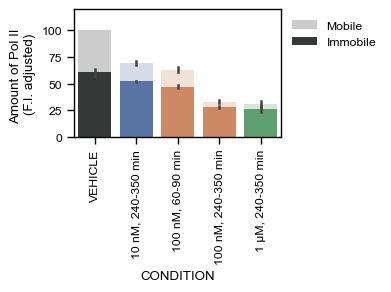

In [61]:
sns.set_context('paper')

f, a = plt.subplots(ncols = 1, figsize = (4,2) )

cp = sns.color_palette(['xkcd:dark grey', 
                        sns.color_palette('deep')[0], 
                        sns.color_palette('deep')[1],
                        sns.color_palette('deep')[1],
                        sns.color_palette('deep')[2], 
                        sns.color_palette('deep')[3]])

sns.barplot(mCloverPolAmountsPerDay, 
            x = 'CONDITION', order = condition_order,
            hue = 'CONDITION', palette = cp,
            y = 'RELATIVE_TOTAL',  
            alpha = 0.25,
           errorbar = 'sd',
           color = 'xkcd:blue green')

sns.barplot(mCloverPolAmountsPerDay, 
            x = 'CONDITION',  order = condition_order,
            hue = 'CONDITION', palette = cp,
            y = 'BOUND', 
            errorbar = ('pi', 100),
           color = 'xkcd:blue green')

a.set_ylim(0,120)

a.set_ylabel('Amount of Pol II \n(F.I. adjusted)')


legend_elements = [Patch(facecolor='xkcd:dark grey',label='Mobile',alpha = 0.25),
                   Patch(facecolor='xkcd:dark grey', label='Immobile')]
a.legend(handles = legend_elements, bbox_to_anchor = (1,1), loc = 'upper left', frameon = False)

plt.tight_layout()
plt.xticks(rotation = 90);

plt.savefig('mACPOLR2A_FRAP_perdaySD.svg')

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_57008/2287910574.py:12: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  sns.barplot(mCloverPolAmountsPerCell,
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_57008/2287910574.py:20: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  sns.barplot(mCloverPolAmountsPerCell,


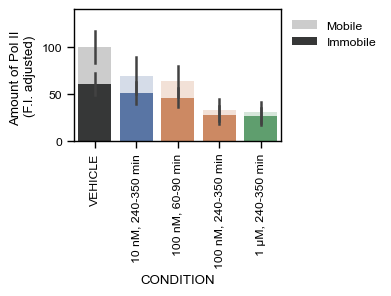

In [62]:
sns.set_context('paper')

f, a = plt.subplots(ncols = 1, figsize = (4,2) )

cp = sns.color_palette(['xkcd:dark grey', 
                        sns.color_palette('deep')[0], 
                        sns.color_palette('deep')[1],
                        sns.color_palette('deep')[1],
                        sns.color_palette('deep')[2], 
                        sns.color_palette('deep')[3]])

sns.barplot(mCloverPolAmountsPerCell, 
            x = 'CONDITION', order = condition_order,
            hue = 'CONDITION', palette = cp,
            y = 'RELATIVE_TOTAL',  
            alpha = 0.25,
           errorbar = 'sd',
           color = 'xkcd:blue green')

sns.barplot(mCloverPolAmountsPerCell, 
            x = 'CONDITION',  order = condition_order,
            hue = 'CONDITION', palette = cp,
            y = 'BOUND', 
            errorbar = 'sd',
           color = 'xkcd:blue green')

a.set_ylim(0,140)

a.set_ylabel('Amount of Pol II \n(F.I. adjusted)')


legend_elements = [Patch(facecolor='xkcd:dark grey',label='Mobile',alpha = 0.25),
                   Patch(facecolor='xkcd:dark grey', label='Immobile')]
a.legend(handles = legend_elements, bbox_to_anchor = (1,1), loc = 'upper left', frameon = False)

plt.tight_layout()
plt.xticks(rotation = 90);

plt.savefig('mACPOLR2A_FRAP_percellSD.svg')

## Compare total POLR2A to bound fraction per condition

In [63]:
xvals = mCloverPolAmountsPerDay[['CONDITION', 'RELATIVE_TOTAL_FC', 'BOUND_FC']].groupby('CONDITION').mean().reset_index()

In [64]:
xerr = mCloverPolAmountsPerDay[['CONDITION', 'RELATIVE_TOTAL_FC', 'BOUND_FC']].groupby('CONDITION').std().reset_index()
xvals['TOTAL_STD'] = xerr['RELATIVE_TOTAL_FC']
xvals['BOUND_STD'] = xerr['BOUND_FC']

In [65]:
xvals

,CONDITION,RELATIVE_TOTAL_FC,BOUND_FC,TOTAL_STD,BOUND_STD
0,"1 µM, 240-350 min",0.307958,0.266452,0.031709,0.026952
1,"10 nM, 240-350 min",0.695217,0.522470,0.022087,0.007839
2,"100 nM, 240-350 min",0.330680,0.281884,0.014852,0.009840
3,"100 nM, 60-90 min",0.633690,0.474465,0.021070,0.017852
4,VEHICLE,1.000000,0.610802,0.000000,0.039430


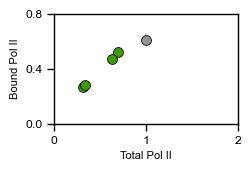

In [66]:
sns.set_context('paper')

f, a = plt.subplots(figsize = (5, 1.8))

a.errorbar(x = xvals.RELATIVE_TOTAL_FC,
              xerr = xvals.TOTAL_STD,
              y = xvals.BOUND_FC,
              yerr = xvals.BOUND_STD,
              linestyle = "None",
              alpha = 0.4, zorder = 1,
              color = 'grey')

h = sns.scatterplot(x = xvals.query('CONDITION == "VEHICLE"').RELATIVE_TOTAL_FC,
                y = xvals.query('CONDITION == "VEHICLE"').BOUND_FC,
                ax = a,
                color = 'xkcd:grey',
                    s = 50, edgecolor = 'black',
                    legend = False)



h = sns.scatterplot(x = xvals.query('CONDITION != "VEHICLE"').RELATIVE_TOTAL_FC,
                y = xvals.query('CONDITION != "VEHICLE"').BOUND_FC,
                ax = a,
                color = 'xkcd:grass green',
                    s = 50, edgecolor = 'black',
                    legend = False)

a.set_box_aspect(0.6)
a.set_ylim(0,0.8)
a.set_yticks([0,0.4,0.8])
a.set_xlim(0,2)
a.set_xticks([0,1.0,2.0])

a.set_xlabel('Total Pol II', fontsize = 8)

a.set_ylabel('Bound Pol II', fontsize = 8)


plt.tight_layout()


plt.savefig('total_vs_bound_mACPOLR2A.svg')

In [67]:
mCloverPolAmountsPerDay['BOUND_FRACTION'] = mCloverPolAmountsPerDay['BOUND'] / mCloverPolAmountsPerDay['RELATIVE_TOTAL']
mCloverPolAmountsPerDay['FREE_FRACTION'] = 1 - mCloverPolAmountsPerDay['BOUND_FRACTION'] 

In [68]:
xvals2 = mCloverPolAmountsPerDay[['CONDITION', 'RELATIVE_TOTAL_FC', 'BOUND_FRACTION', 'FREE_FRACTION']].groupby('CONDITION').mean().reset_index()
xerr2 = mCloverPolAmountsPerDay[['CONDITION', 'RELATIVE_TOTAL_FC', 'BOUND_FRACTION', 'FREE_FRACTION']].groupby('CONDITION').std().reset_index()
xvals2['TOTAL_STD'] = xerr2['RELATIVE_TOTAL_FC']
xvals2['BOUND_FRACTION_STD'] = xerr2['BOUND_FRACTION']
xvals2['FREE_FRACTION_STD'] = xerr2['FREE_FRACTION']

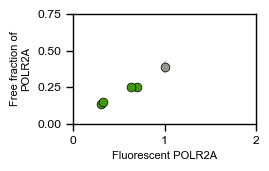

In [69]:
sns.set_context('paper')

f, a = plt.subplots(figsize = (5, 1.8))

a.errorbar(x = xvals2.RELATIVE_TOTAL_FC,
              xerr = xvals2.TOTAL_STD,
              y = xvals2.FREE_FRACTION,
              yerr = xvals2.FREE_FRACTION_STD,
              linestyle = "None",
              alpha = 0.6, zorder = 1,
              color = 'grey')

h = sns.scatterplot(x = xvals2.query('CONDITION == "VEHICLE"').RELATIVE_TOTAL_FC,
                y = xvals2.query('CONDITION == "VEHICLE"').FREE_FRACTION,
                ax = a,
                color = 'xkcd:grey',
                    s = 40, edgecolor = 'black',
                    legend = False)



h = sns.scatterplot(x = xvals2.query('CONDITION != "VEHICLE"').RELATIVE_TOTAL_FC,
                y = xvals2.query('CONDITION != "VEHICLE"').FREE_FRACTION,
                ax = a,
                color = 'xkcd:grass green',
                    s = 40, edgecolor = 'black',
                    legend = False)

a.set_box_aspect(0.6)
a.set_ylim(0,0.75)
a.set_yticks([0, 0.25, 0.5, 0.75])
a.set_xlim(0,2)
a.set_xticks([0,1.0,2.0])


a.set_xlabel('Fluorescent POLR2A', fontsize = 8)

a.set_ylabel('Free fraction of\nPOLR2A', fontsize = 8)


plt.tight_layout()


plt.savefig('total_vs_free_fraction_mACPOLR2A_yscale.svg')

In [70]:
mClover_Normalised_Data.CONDITION.unique()

array(['VEHICLE', '10 nM, 240-350 min', '100 nM, 60-90 min',
       '100 nM, 240-350 min', '1 µM, 240-350 min'], dtype=object)

In [71]:
condition_order

['VEHICLE',
 '10 nM, 240-350 min',
 '100 nM, 60-90 min',
 '100 nM, 240-350 min',
 '1 µM, 240-350 min']

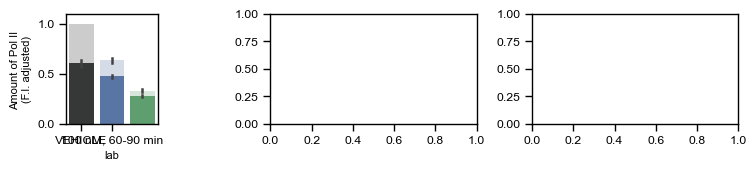

In [72]:
sns.set_context('paper')

f, a = plt.subplots(ncols = 3, figsize = (8,1.8) )

cp = sns.color_palette(['xkcd:dark grey', 
                        sns.color_palette('deep')[0],
                        sns.color_palette('deep')[2]])


mCloverPolAmountsPerDay['RELATIVE_TOTAL_FC'] = mCloverPolAmountsPerDay['RELATIVE_TOTAL'] / 100
mCloverPolAmountsPerDay['BOUND_FC'] = mCloverPolAmountsPerDay['BOUND'] / 100

sns.barplot(mCloverPolAmountsPerDay, 
            x = 'CONDITION', order = [condition_order[0],condition_order[2],condition_order[3]],
            hue = 'CONDITION', hue_order = [condition_order[0],condition_order[2],condition_order[3]], palette = cp,
            y = 'RELATIVE_TOTAL_FC',  
            alpha = 0.25,
           errorbar = 'sd',
           color = 'xkcd:blue green',
            ax = a[0])

sns.barplot(mCloverPolAmountsPerDay, 
            x = 'CONDITION',  order = [condition_order[0],condition_order[2],condition_order[3]],
            hue = 'CONDITION', hue_order = [condition_order[0],condition_order[2],condition_order[3]],
            palette = cp,
            y = 'BOUND_FC', 
            errorbar = ('pi', 100),
           color = 'xkcd:blue green',
            ax = a[0])

a[0].set_ylim(0,1.1)

a[0].set_ylabel('Amount of Pol II \n(F.I. adjusted)', fontsize = 8)
a[0].set_xlabel('lab', fontsize = 8)
a[0].set_xticks([0,1])

a[0].set_box_aspect(1.2)

plt.tight_layout()

plt.savefig('mACPOLR2A_FRAP_10nM_1uM_perdaySD.svg')

In [73]:
mCloverPolAmountsPerDay.to_csv('mACPOLR2A_biallelic_FRAP_Bound_Free_RelativeTotal.csv')

In [74]:
mCloverPolAmountsPerDay.query('CONDITION == "10 nM, 240-350 min"')['RELATIVE_TOTAL'].mean(),mCloverPolAmountsPerDay.query('CONDITION == "10 nM, 240-350 min"')['RELATIVE_TOTAL'].std()

(69.52173021913268, 2.2086950968610632)

# Compare intensities in FRAP experiment to fixed cell (mACPOLR2A Kinetic pSer2 experiment) to confirm loss of GFP is similar

In [75]:
mClover_On_DF_ByDay = mClover_On_DF.drop(['FILE'], axis = 1).groupby(['DATE','CONDITION']).mean().reset_index()

In [76]:
mClover_On_DF_ByDay

,DATE,CONDITION,AREA,INTENSITY_MCLOVER,INTENSITY_MCLOVER_NORM
0,250926,"1 µM, 240-350 min",15730.466667,7.449218,18.973322
1,250926,"10 nM, 240-350 min",16602.600000,15.088872,60.223501
2,250926,"100 nM, 240-350 min",15420.933333,7.848287,21.128086
3,250926,"100 nM, 60-90 min",15485.400000,14.250908,55.698930
4,250926,VEHICLE,16525.200000,22.455596,100.000000
5,250929,"1 µM, 240-350 min",14943.333333,6.357162,14.080972
6,250929,"10 nM, 240-350 min",14681.000000,15.500097,67.239067
7,250929,"100 nM, 240-350 min",16414.666667,8.284081,25.284300
8,250929,"100 nM, 60-90 min",15017.933333,13.689102,56.709728
9,250929,VEHICLE,15211.600000,21.134819,100.000000


In [77]:
yvals = mClover_On_DF_ByDay.drop(['DATE'], axis = 1).groupby('CONDITION')['INTENSITY_MCLOVER_NORM'].mean().reset_index()
yerr = mClover_On_DF_ByDay.drop(['DATE'], axis = 1).groupby('CONDITION').std().reset_index()['INTENSITY_MCLOVER_NORM'].values

In [78]:
yvals['YERR'] = yerr
YVALS = yvals.rename(columns = {"INTENSITY_MCLOVER_NORM" : "YVALS"})

In [79]:
XVALS = pd.read_csv('XVALS.csv')

In [80]:
FIXED384_VS_FRAP = YVALS.merge(XVALS, left_on = 'CONDITION', right_on = 'CONDITION')

Text(0, 0.5, 'GFP_INTENSITY_FRAP')

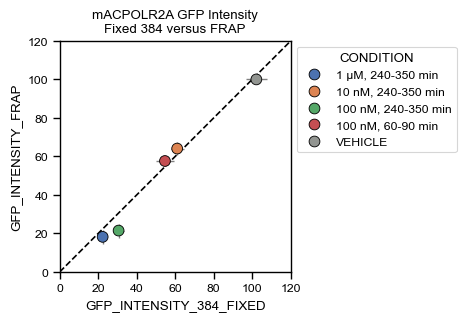

In [81]:
sns.set_context('paper')

f, a = plt.subplots(figsize = (3,3))

plt.axline((0,0), slope=1, linestyle = '--', color = 'black', zorder = 0)

cp = sns.color_palette([sns.color_palette('deep')[0], 
                        sns.color_palette('deep')[1],
                        sns.color_palette('deep')[2], 
                        sns.color_palette('deep')[3],
                        'xkcd:grey'])


plt.errorbar(x = FIXED384_VS_FRAP.XVALS,
             xerr = FIXED384_VS_FRAP.XERR,
             y = FIXED384_VS_FRAP.YVALS,
             yerr = FIXED384_VS_FRAP.YERR,
             linestyle = "None", linewidth = 1,
             color = 'grey', zorder = 1)

g = sns.scatterplot(x = FIXED384_VS_FRAP.XVALS,
                y = FIXED384_VS_FRAP.YVALS,
                hue = FIXED384_VS_FRAP.CONDITION,
                palette = cp,
                s = 60,
                edgecolor = 'black')

sns.move_legend(g, 'upper left', bbox_to_anchor = (1,1))

a.set_box_aspect(1)



plt.xlim(0,120)
plt.ylim(0,120)

a.set_title('mACPOLR2A GFP Intensity\nFixed 384 versus FRAP')

plt.xlabel('GFP_INTENSITY_384_FIXED')
plt.ylabel('GFP_INTENSITY_FRAP')